In [ ]:
# !pip install plotly
# !pip install nbformat
# !pip install arabic-reshaper python-bidi

<div dir="rtl">

###  بخش اول: ساخت جدول  (Golden Dataset)
در این سلول، داده‌های استخراج‌شده از رفتار کاربران (مانند بازدید و خرید) با خروجی‌های پیشرفته‌ی تحلیل احساسات مبتنی بر جنبه (ABSA) ادغام می‌شوند. 
هدف ما ساخت یک دیتامارت جامع و یکپارچه است تا بتوانیم تأثیر مستقیم «احساسات و نظرات» را روی «رفتار واقعی کاربر و فروش» بررسی کنیم.

</div>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

# تنظیم استایل پیش‌فرض
sns.set_theme(style="whitegrid", rc={"font.family": "Tahoma"})

# مسیرها
FEATURE_DIR = Path('../Dataset/Feature_KPI_output')
ABSA_DIR = Path('../Dataset/ABSA_KPI')

print("⏳ در حال بارگذاری و ادغام جداول...")

# ۱. لود کردن جداول اصلی
df_absa = pd.read_parquet(ABSA_DIR / "product_master_absa.parquet")
df_behavior = pd.read_parquet(FEATURE_DIR / "product_master.parquet")

# ۲. ادغام (Join) جداول: چسباندن رفتار کاربر به احساسات بر اساس ID محصول
cols_to_merge = ['id', 'is_view', 'is_cart', 'is_purchase', 'conversion_rate']
df_golden = pd.merge(
    df_absa, 
    df_behavior[cols_to_merge], 
    on='id', 
    how='inner'
)

# ۳. لود کردن سایر جداول مورد نیاز
df_aspect_kpi = pd.read_parquet(ABSA_DIR / "aspect_kpi.parquet")
df_user_logs = pd.read_parquet(FEATURE_DIR / "user_behavior_enriched.parquet")

print("✅ دیتامارت نهایی آماده شد!")
print(f"📦 ابعاد جدول فوق‌طلایی (احساسات + رفتار): {df_golden.shape}")

⏳ در حال بارگذاری و ادغام جداول...
✅ دیتامارت نهایی آماده شد!
📦 ابعاد جدول فوق‌طلایی (احساسات + رفتار): (948352, 20)


<div dir="rtl">

### 🫧 بخش دوم: تحلیل تقاطعی قیمت، فروش و احساسات (Bubble Scatter Plot)
**این نمودار چه می‌گوید؟**
این نمودار سه‌بعدی و تعاملی به ما نشان می‌دهد که آیا احساسات مثبت می‌تواند فروش کالاهای گران‌تر را تضمین کند یا خیر.
* **محور افقی (X):** قیمت محصول (نمایش به صورت لگاریتمی برای درک بهتر).
* **محور عمودی (Y):** نرخ تبدیل به خرید (Conversion Rate).
* **اندازه حباب:** نشان‌دهنده تعداد کل نظرات ثبت‌شده برای آن محصول.
* **رنگ حباب:** امتیاز احساسات (سبز = مثبت، قرمز = منفی).

*💡 راهنما: با بردن نشانگر موس روی هر حباب می‌توانید نام محصول، برند و ویژگی برتر آن را مشاهده کنید!*

</div>

In [7]:
# ==========================================
# ۲. تحلیل تقاطعی: قیمت در برابر نرخ خرید، با رنگ‌آمیزی احساسات
# ==========================================

# فیلتر: 
# ۱. قیمت بزرگتر از صفر
# ۲. حداقل ۲۰ بازدید برای حذف دیتای پرت
# ۳. حذف محصولاتی که کامنت ندارند (برای جلوگیری از خطای NaN در اندازه حباب)
df_bubble = df_golden[
    (df_golden['Price'] > 0) & 
    (df_golden['is_view'] >= 20) &
    (df_golden['total_comments'].notna()) &  # مقادیر خالی (NaN) را حذف کن
    (df_golden['total_comments'] > 0)        # فقط آن‌هایی که واقعا کامنت دارند
].copy()

# برای احتیاط، اگر امتیاز احساساتی خالی بود آن را صفر (خنثی) در نظر بگیر
df_bubble['sentiment_score'] = df_bubble['sentiment_score'].fillna(0)

# رسم نمودار تعاملی با Plotly
fig = px.scatter(
    df_bubble,
    x="Price",
    y="conversion_rate",
    size="total_comments",     # اندازه حباب: تعداد کامنت
    color="sentiment_score",   # رنگ حباب: امتیاز احساسات (سبز=مثبت، قرمز=منفی)
    hover_name="title_fa",     # متن هاور
    hover_data=["Brand", "is_view", "is_purchase", "top_aspect"],
    color_continuous_scale=px.colors.diverging.RdYlGn,
    title="Bubble Scatter: Price vs Conversion Rate (Colored by Sentiment)",
    labels={"Price": "Price (Toman)", "conversion_rate": "Conversion Rate"},
    log_x=True, # محور افقی لگاریتمی برای نمایش بهتر
    size_max=45
)

fig.update_layout(height=600, template="plotly_white")
fig.show()

<div dir="rtl">

### 🌡️ بخش سوم: نقشه حرارتی همبستگی ویژگی‌ها (Correlation Heatmap)
**این نمودار چه می‌گوید؟**
این ماتریس نشان می‌دهد که متغیرهای مختلف رفتار و احساسات چقدر با هم ارتباط منطقی دارند. اعداد به ۱ (همبستگی مثبت کامل) و -۱ (همبستگی منفی کامل) متمایل می‌شوند.
این نمودار پیش‌نیاز اصلی برای فاز **«خوشه‌بندی (Clustering) و یادگیری ماشین»** است؛ زیرا به ما کمک می‌کند ویژگی‌های تکراری و دارای همبستگی بالا را شناسایی و مدیریت کنیم تا مدل نهایی دچار گیجی (Overfitting) نشود.

</div>

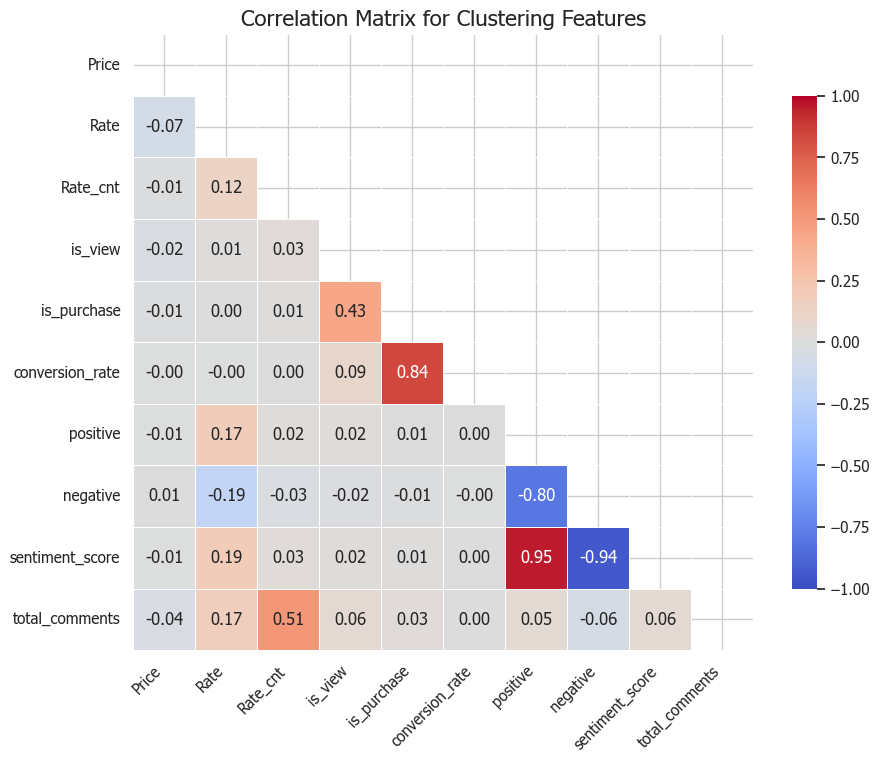

In [8]:
# ==========================================
# ۳. ماتریس همبستگی ویژگی‌ها برای انتخاب فیچرهای مدل ML
# ==========================================
plt.figure(figsize=(10, 8))

# انتخاب ستون‌های عددی موجود در جدول فوق‌طلایی
numeric_cols = [
    'Price', 'Rate', 'Rate_cnt', 
    'is_view', 'is_purchase', 'conversion_rate',
    'positive', 'negative', 'sentiment_score', 'total_comments'
]

corr_matrix = df_golden[numeric_cols].corr()

# رسم هیت‌مپ
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmax=1, vmin=-1, 
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title("Correlation Matrix for Clustering Features", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

<div dir="rtl">

### 🎻 بخش چهارم: توزیع احساسات در برندهای پرفروش (Violin Plot)
**این نمودار چه می‌گوید؟**
این نمودار ویولن نشان‌دهنده پراکندگی و توزیع احساسات کاربران نسبت به ۱۰ برند برتر و پربازدید است.
* اگر شکم ویولن در اطراف خط قرمز (صفر) کشیده شده باشد، یعنی نظرات کاربران بیشتر خنثی است.
* اگر ویولن در دو سر بالا و پایین پهن باشد (شکل ساعت شنی)، یعنی برند **دوقطبی** است (عده‌ای شدیداً راضی و عده‌ای شدیداً ناراضی‌اند).
* تمایل حجم ویولن به سمت بالای خط قرمز، نشان‌دهنده موفقیت برند در جلب رضایت مشتریان است.

</div>

C:\Users\User\AppData\Local\Temp\ipykernel_5520\235482941.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
C:\Users\User\AppData\Local\Temp\ipykernel_5520\235482941.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


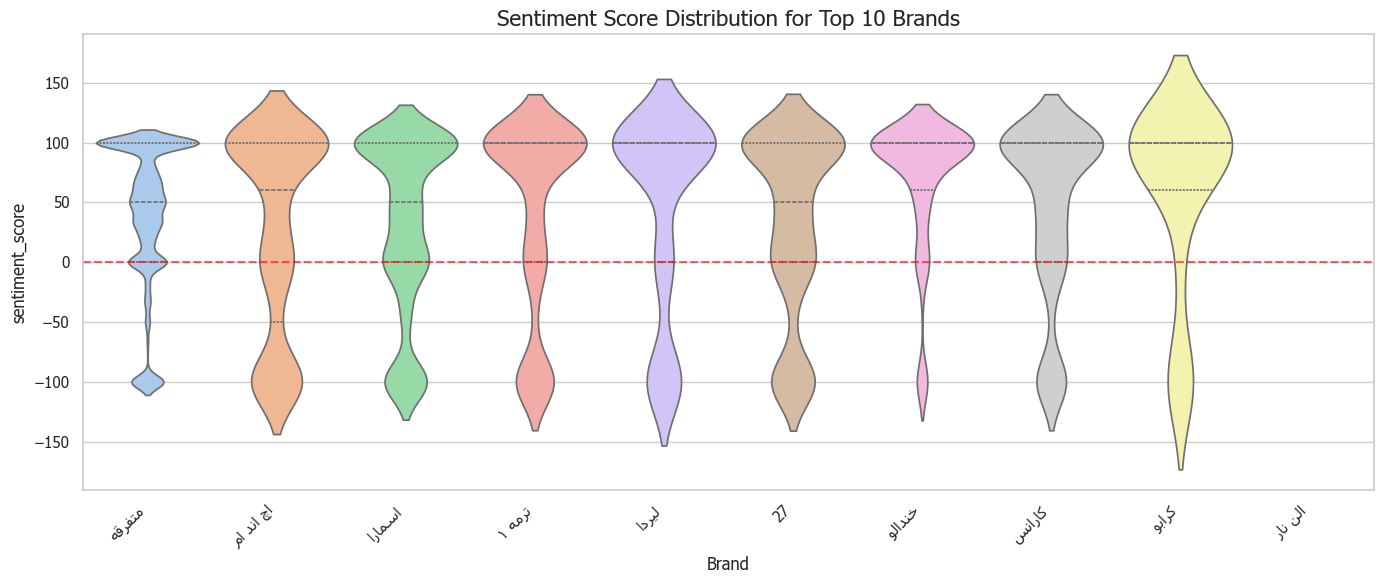

In [3]:
# ==========================================
# ۴. بررسی دوقطبی بودن احساسات در برندهای پرفروش
# (اصلاح‌شده برای متون فارسی)
# ==========================================

import arabic_reshaper
from bidi.algorithm import get_display

plt.figure(figsize=(14, 6))

# پیدا کردن ۱۰ برند برتر
top_brands = df_golden["Brand"].value_counts().head(10).index

df_top_brands = df_golden[
    df_golden["Brand"].isin(top_brands)
]

# رسم نمودار ویولن
ax = sns.violinplot(
    data=df_top_brands,
    x="Brand",
    y="sentiment_score",
    palette="pastel",
    inner="quartile",
)

plt.title(
    "Sentiment Score Distribution for Top 10 Brands",
    fontsize=16,
)

# خط صفر به عنوان مرز احساس خنثی
plt.axhline(
    0,
    color="red",
    linestyle="--",
    alpha=0.6,
)

# ==========================================
# بخش جادویی برای نمایش صحیح متن فارسی
# ==========================================

# گرفتن متن برچسب‌های محور افقی
labels = [item.get_text() for item in ax.get_xticklabels()]

# اصلاح اتصال حروف و راست‌به‌چپ کردن متن
persian_labels = [
    get_display(arabic_reshaper.reshape(label))
    for label in labels
]

# جایگزینی برچسب‌های اصلاح‌شده
ax.set_xticklabels(
    persian_labels,
    rotation=45,
    ha="right",
)

# ==========================================

plt.tight_layout()
plt.show()

<div dir="rtl">

### 📊 بخش پنجم: تحلیل نقاط قوت و ضعف ویژگی‌های کالا (Diverging Bar Chart)
**این نمودار چه می‌گوید؟**
این نمودار خروجی مستقیم ترکیب پردازش زبان طبیعی (NLP) با هوش تجاری است. ۱۵ ویژگی (Aspect) که بیشترین تکرار را در کامنت‌ها داشته‌اند استخراج شده و به دو دسته احساسات مثبت (میله‌های سبز) و منفی (میله‌های قرمز) تقسیم شده‌اند. 
مدیران کسب‌وکار با یک نگاه به این نمودار متوجه می‌شوند که مثلاً آیا مشتریان بیشتر از «کیفیت» محصولات راضی هستند یا از «بسته‌بندی» و «قیمت» شکایت دارند.

</div>

In [10]:
# ==========================================
# ۵. تحلیل نقاط قوت و ضعف ویژگی‌های محصولات (Aspects)
# ==========================================
# استخراج ۱۵ ویژگی که بیشترین تکرار را داشته‌اند
top_aspects = df_aspect_kpi.nlargest(15, 'total_mentions').sort_values('total_mentions', ascending=True)

fig = go.Figure()

# درصد منفی (رسم به سمت چپ)
fig.add_trace(go.Bar(
    y=top_aspects['aspect'],
    x=-top_aspects['negative'], 
    name='Negative %',
    orientation='h',
    marker=dict(color='indianred'),
    text=top_aspects['negative'].round(1).astype(str) + '%'
))

# درصد مثبت (رسم به سمت راست)
fig.add_trace(go.Bar(
    y=top_aspects['aspect'],
    x=top_aspects['positive'],
    name='Positive %',
    orientation='h',
    marker=dict(color='mediumseagreen'),
    text=top_aspects['positive'].round(1).astype(str) + '%'
))

fig.update_layout(
    title="Top 15 Aspects: Positive vs Negative Sentiment",
    barmode='overlay',
    xaxis_title="Percentage (%)",
    height=600,
    template="plotly_white",
    hovermode="y unified"
)
fig.show()

<div dir="rtl">

### 🎯 بخش ششم: تحلیل قیف فروش و رفتار شبانه‌روزی کاربران
**این نمودارها چه می‌گویند؟**
در این بخش رفتار خام کاربران را به دو شاخص کلیدی مارکتینگ تبدیل کرده‌ایم:
۱. **قیف تعاملی (Conversion Funnel):** نشان می‌دهد از کل افرادی که محصولات را دیده‌اند، چه کسری از آن‌ها کالا را به سبد خرید اضافه کرده و در نهایت چه کسری واقعاً پول پرداخت کرده‌اند (شناسایی گلوگاه‌های ریزش مشتری).
۲. **روند شبانه‌روزی (Dual-Axis Time Series):** مقایسه ساعت‌به‌ساعتِ تعداد بازدیدها (خط آبی) با خریدهای واقعی (خط نارنجی). این نمودار حیاتی نشان می‌دهد در چه ساعاتی کاربران فقط «ویترین‌گردی» می‌کنند و چه زمانی بهترین فرصت برای اجرای کمپین‌های فروش است.

</div>

In [12]:
# ==========================================
# ۶. قیف فروش و سری زمانی از روی لاگ رفتار
# ==========================================
# الف) قیف فروش با استفاده از ستون‌های دودویی (is_view, ...)
total_views = df_user_logs['is_view'].sum()
total_carts = df_user_logs['is_cart'].sum()
total_purchases = df_user_logs['is_purchase'].sum()

fig_funnel = px.funnel(
    x=[total_views, total_carts, total_purchases], 
    y=["View", "Add to Cart", "Purchase"],
    title="Interactive Conversion Funnel",
    color_discrete_sequence=['#835AF1']
)
fig_funnel.update_layout(height=350, template="plotly_white")
fig_funnel.show()

# ب) روند شبانه‌روزی رفتار
hourly_stats = df_user_logs.groupby('hour')[['is_view', 'is_purchase']].sum().reset_index()

fig_time = make_subplots(specs=[[{"secondary_y": True}]])

# خط بازدیدها
fig_time.add_trace(
    go.Scatter(x=hourly_stats['hour'], y=hourly_stats['is_view'], name="Views", mode="lines+markers", line=dict(color='royalblue')),
    secondary_y=False,
)
# خط خریدها
fig_time.add_trace(
    go.Scatter(x=hourly_stats['hour'], y=hourly_stats['is_purchase'], name="Purchases", mode="lines+markers", line=dict(color='darkorange')),
    secondary_y=True,
)

fig_time.update_layout(title_text="Hourly Trend: Views vs Purchases", template="plotly_white")
fig_time.show()